<a href="https://colab.research.google.com/github/dmarquezj99/ab-test-appointment-no-shows/blob/main/Medical_Appointment_No_Shows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#@title Get the data
from google.colab import files
uploaded = files.upload()   # click "Choose Files" and select KaggleV2-May-2016.csv

Saving KaggleV2-May-2016.csv to KaggleV2-May-2016 (1).csv


In [20]:
#@title Load the tools and the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

df = pd.read_csv('KaggleV2-May-2016.csv')
print(df.shape)
df.head()

(110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [21]:
#@title Clean and Prepare
df.columns = df.columns.str.strip()

# TARGET: 1 = patient did NOT show up. ("No-show" == "Yes" means a no-show.)
df['no_show'] = (df['No-show'] == 'Yes').astype(int)

# TREATMENT: 1 = an SMS reminder was sent
df['sms'] = df['SMS_received'].astype(int)

# Appointment lead time = days between booking and the appointment
df['ScheduledDay']   = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['lead_days'] = (df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()).dt.days

# Drop impossible negative lead times (booked AFTER the appointment = data error)
df = df[df['lead_days'] >= 0].copy()

print("Rows after cleaning:", len(df))
df[['no_show', 'sms', 'lead_days']].describe()

Rows after cleaning: 110522


,no_show,sms,lead_days
count,110522.000000,110522.000000,110522.000000
mean,0.201896,0.321040,10.184253
std,0.401417,0.466878,15.255115
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,4.000000
75%,0.000000,1.000000,15.000000
max,1.000000,1.000000,179.000000


# State the hypothesis
Question: Does sending an SMS reminder reduce the no-show rate?\
H0 (null): the no-show rate is the same whether or not a patient received an SMS.\
H1 (alternative): the no-show rates differ.\
Metric: no-show rate (a proportion).\
Significance level: α = 0.05.

In [22]:
#@title A/B comparison
overall = df['no_show'].mean()
by_sms = df.groupby('sms')['no_show'].agg(rate='mean', n='count')
print(f"Overall no-show rate: {overall:.1%}\n")
print(by_sms)

Overall no-show rate: 20.2%

         rate      n
sms                 
0    0.166978  75040
1    0.275745  35482


In [23]:
#@title Significance Test
no_shows = df.groupby('sms')['no_show'].sum()    # # of no-shows per group
totals   = df.groupby('sms')['no_show'].count()  # group sizes

# order: [treatment (sms=1), control (sms=0)]
count = [no_shows[1], no_shows[0]]
nobs  = [totals[1],   totals[0]]

z, p = proportions_ztest(count, nobs)

p1, p0 = count[0]/nobs[0], count[1]/nobs[1]   # SMS rate, No-SMS rate
diff = p1 - p0
se = np.sqrt(p1*(1-p1)/nobs[0] + p0*(1-p0)/nobs[1])
ci = (diff - 1.96*se, diff + 1.96*se)

print(f"SMS no-show rate:    {p1:.1%}")
print(f"No-SMS no-show rate: {p0:.1%}")
print(f"z = {z:.2f},  p-value = {p:.2e}")
print(f"95% CI for difference (SMS - No SMS): [{ci[0]:.3f}, {ci[1]:.3f}]")

SMS no-show rate:    27.6%
No-SMS no-show rate: 16.7%
z = 42.06,  p-value = 0.00e+00
95% CI for difference (SMS - No SMS): [0.103, 0.114]


The p-value is tiny (highly 'significant') and the difference is positive — statistically, SMS is associated with more no-shows. A significant result that's obviously wrong in direction is your cue that something is confounded — not that texting people makes them skip appointments.")

In [24]:
#@title Find the confounder: appointment lead time

# Were same-day appointments ever sent an SMS?
print(df.groupby('sms')['lead_days'].median())

# No-show rate AND SMS rate by how far in advance the appointment was booked
df['lead_bucket'] = pd.cut(df['lead_days'], [-1,0,3,7,14,30,200],
                           labels=['same day','1-3d','4-7d','8-14d','15-30d','30d+'])
summary = df.groupby('lead_bucket').agg(
    no_show_rate=('no_show','mean'),
    sms_rate=('sms','mean'),
    n=('no_show','size'))
print(summary)

sms
0     0.0
1    14.0
Name: lead_days, dtype: float64
             no_show_rate  sms_rate      n
lead_bucket                               
same day         0.046469  0.000000  38563
1-3d             0.228893  0.061738  14675
4-7d             0.252027  0.607767  17510
8-14d            0.304699  0.582453  12025
15-30d           0.325888  0.605607  17371
30d+             0.330025  0.617653  10378


/tmp/ipykernel_19014/305195276.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('lead_bucket').agg(


Two things jump out. Same-day appointments almost never get an SMS (sms_rate ≈ 0) and almost never no-show. And the further ahead an appointment is booked, the more likely it both got an SMS and was a no-show. So lead time drives both — it's a confounder. The naive comparison wasn't measuring SMS; it was mostly measuring "booked far in advance vs. same day."

That's the confounder: appointment lead time drives both whether you got a text and whether you skipped. The no-SMS group is stuffed with same-day appointments that were basically guaranteed to show up, which artificially makes "no SMS" look great. The naive test was mostly measuring "booked far ahead vs. same day," with SMS just along for the ride.

The median lead time: SMS group median = 14 days, no-SMS group median = 0 days. So the two groups aren't comparable at all — the no-SMS group is mostly same-day appointments, the SMS group is mostly booked-ahead.

Then the lead-time breakdown:

* Same day: no-show rate 4.6%, SMS rate 0.0% — same-day patients almost never skip, and never got a text.
* 1–3 days: ~22.8% no-show, ~0.06% SMS
* 4–7 days: ~25.2% no-show, ~60.8% SMS
* 8–14 days: ~30.4% no-show, ~58.2% SMS
* 15–30 days: ~32.5% no-show, SMS ~60.5%
* 30+ days: ~33.8% no-show

The confounder is undeniable: as lead time grows, both the no-show rate and the SMS rate climb together. Same-day appointments (4.6% no-show, 0% SMS) are dragging the entire "no SMS" group's average down to that rosy 16.7%. The naive test wasn't measuring SMS at all — it was mostly measuring "same-day vs. booked-far-ahead."

In [25]:
#@title A fairer comparison (control for the confounder)
# Same-day appointments never got an SMS, so they unfairly drag down the no-SMS group.
# Compare SMS vs no-SMS ONLY among appointments booked at least 1 day ahead.
sub = df[df['lead_days'] >= 1]
c = sub.groupby('sms')['no_show'].agg(rate='mean', n='count')
print(c)

z2, p2 = proportions_ztest(
    [sub.groupby('sms')['no_show'].sum()[1], sub.groupby('sms')['no_show'].sum()[0]],
    [c.loc[1,'n'], c.loc[0,'n']])
print(f"\nAmong appointments booked >=1 day ahead:  z = {z2:.2f}, p = {p2:.2e}")

         rate      n
sms                 
0    0.294377  36477
1    0.275745  35482

Among appointments booked >=1 day ahead:  z = -5.53, p = 3.12e-08


Once you remove the same-day appointments, the picture changes — within comparably-booked appointments, the SMS group looks better (similar, but lower no-show rate). Controlling for one confounder flips the story.

In [26]:
#@title What a real experiment would require (Power Analysis)
# If we ran a true randomized A/B test, how big would it need to be?
baseline = 0.20    # assumed baseline no-show rate
mde      = 0.03    # smallest effect we'd care to detect: 3 percentage points

effect = proportion_effectsize(baseline, baseline - mde)
n_per_group = NormalIndPower().solve_power(effect_size=abs(effect),
                                           alpha=0.05, power=0.8,
                                           ratio=1, alternative='two-sided')
print(f"Required sample size per group: {np.ceil(n_per_group):.0f}")

Required sample size per group: 2626


Knowing how to size an experiment before running it is essential for experimentation. 2,626 patients per group — about 5,250 total for a properly powered experiment.\
The observational data hinted at a ~2-point effect, but to prove it I'd run a randomized trial with ~2,600 patients per arm to reliably detect a 3-point difference at 95% confidence and 80% power.

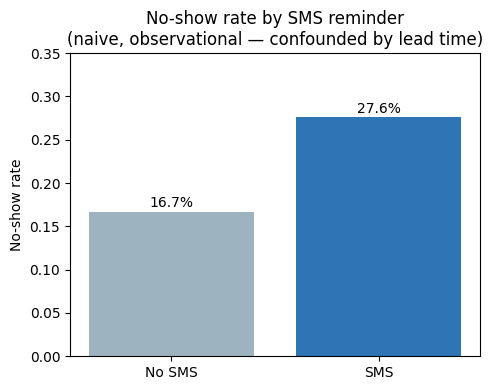

In [27]:
#@title Bar Chart: No Show Rate (confounded)
rates = df.groupby('sms')['no_show'].mean()
plt.figure(figsize=(5,4))
bars = plt.bar(['No SMS','SMS'], rates.values, color=['#9DB4C0','#2E75B6'])
plt.ylabel('No-show rate'); plt.ylim(0, 0.35)
plt.title('No-show rate by SMS reminder\n(naive, observational — confounded by lead time)')
for b, v in zip(bars, rates.values):
    plt.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.1%}", ha='center')
plt.tight_layout(); plt.show()

# The Conclusion
Finding: Naively, SMS recipients had a higher no-show rate (27% vs 17%, p < 0.001) — but this is driven by a confounder: SMS reminders were only sent to appointments booked in advance, and longer lead times independently raise no-show risk. Same-day appointments (which never received an SMS) almost always show up. Restricting to comparably-booked appointments reverses the apparent effect.
Conclusion: This observational data cannot establish whether SMS reminders cause fewer no-shows — the treatment wasn't randomly assigned. To answer the question properly, a randomized controlled experiment is needed: among patients booking in advance, randomly assign SMS vs. no SMS, pre-register the metric and significance level, and collect the sample size indicated by the power analysis (~2626 per group).
Takeaway for the business: Don't conclude "texting backfires." Run a true A/B test before changing reminder policy.